# Cryptocurrency Volatility Analysis
This notebook analyzes the volatility and risk characteristics of 10 major
cryptocurrencies. It computes annualized volatility, rolling volatility trends,
return distributions, monthly volatility heatmaps, and Sharpe ratios to provide
a comprehensive risk profile for each cryptocurrency.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [19]:
os.makedirs("../data/volatility", exist_ok=True)

## Load Dataset
Load the preprocessed combined cryptocurrency dataset from `data/processed/`.

In [ ]:
df = pd.read_csv("../data/processed/combined_crypto_data.csv", parse_dates=["Date"])

print("Shape:", df.shape)
print("Cryptos:", df["Crypto"].unique())
df.head()

Shape: (18250, 14)
Cryptos: ['ADA' 'BNB' 'BTC' 'DOGE' 'DOT' 'ETH' 'LINK' 'LTC' 'SOL' 'XRP']


,Date,Open,High,Low,Close,Volume,Crypto,Daily_Return,Log_Return,Price_Range,MA_7,MA_30,Volatility_7,Cumulative_Return
0,2021-01-01,0.181382,0.184246,0.172022,0.175350,1122218004,ADA,NaN,NaN,0.012224,NaN,NaN,NaN,0.000000
1,2021-01-02,0.175359,0.184253,0.169233,0.177423,1408849504,ADA,1.182210,0.011753,0.015020,NaN,NaN,NaN,1.182210
2,2021-01-03,0.177382,0.208679,0.173376,0.204995,2303857909,ADA,15.540266,0.144449,0.035303,NaN,NaN,NaN,16.906194
3,2021-01-04,0.205236,0.239661,0.194450,0.224762,3260699086,ADA,9.642667,0.092056,0.045211,NaN,NaN,NaN,28.179070
4,2021-01-05,0.224817,0.264886,0.208454,0.258314,4097207384,ADA,14.927800,0.139134,0.056432,NaN,NaN,NaN,47.313385


## Annualized Volatility per Cryptocurrency
Annualized volatility measures the degree of price fluctuation over a year.

**Formula:**
$$\text{Annualized Volatility} = \sigma_{daily} \times \sqrt{365}$$

- Higher volatility = higher risk
- Crypto markets operate 365 days/year (unlike stock markets at 252 days)

In [ ]:
# Annualized volatility = std of daily returns * sqrt(365)
volatility_summary = df.groupby("Crypto")["Daily_Return"].std() * np.sqrt(365)
volatility_summary = volatility_summary.sort_values(ascending=False).reset_index()
volatility_summary.columns = ["Crypto", "Annualized_Volatility"]

print("Annualized Volatility (%):")
print(volatility_summary)

Annualized Volatility (%):
  Crypto  Annualized_Volatility
0   DOGE             206.251375
1    SOL             113.885780
2    XRP             103.489038
3   LINK             101.241105
4    ADA              99.670436
5    DOT              98.666114
6    LTC              86.103204
7    BNB              84.198671
8    ETH              78.827187
9    BTC              58.462253


## Bar Chart — Annualized Volatility
Visualize and rank all cryptocurrencies by their annualized volatility.
Cryptos at the top are the riskiest; those at the bottom are most stable.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10768\1251242083.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=volatility_summary, x="Crypto", y="Annualized_Volatility", palette="Reds_r")


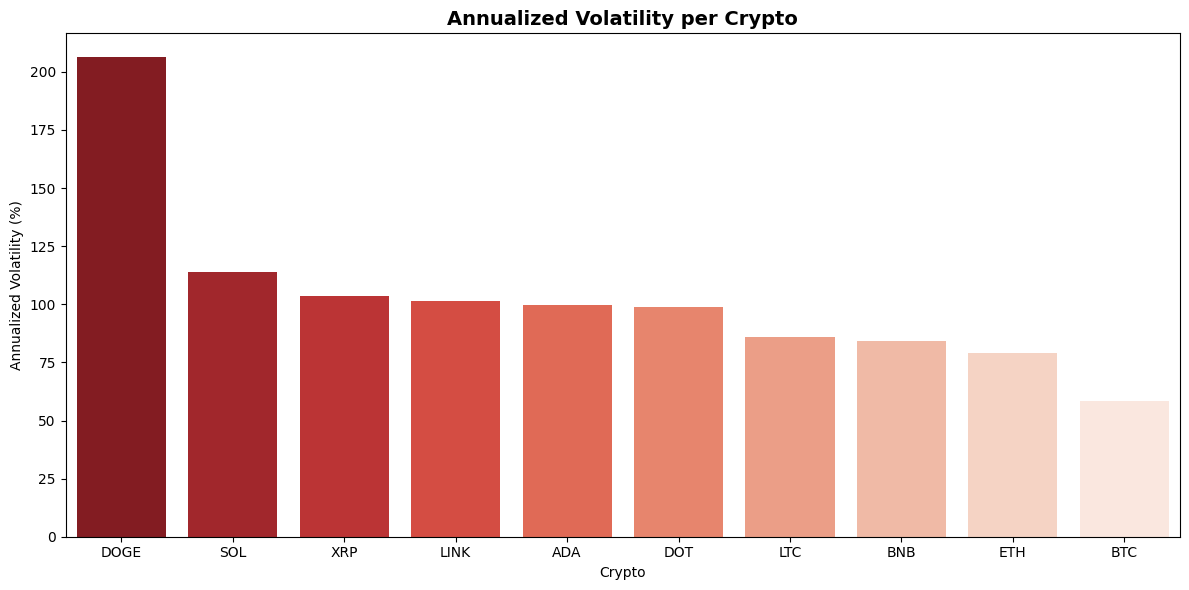

Saved: annualized_volatility.png


In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=volatility_summary, x="Crypto", y="Annualized_Volatility", palette="Reds_r")
plt.title("Annualized Volatility per Crypto", fontsize=14, fontweight="bold")
plt.xlabel("Crypto")
plt.ylabel("Annualized Volatility (%)")
plt.tight_layout()
plt.savefig("../data/volatility/annualized_volatility.png", dpi=150)
plt.show()
print("Saved: annualized_volatility.png")

## 30-Day Rolling Volatility — All Cryptos
Rolling volatility shows how risk levels change over time for each cryptocurrency.

**Formula:**
$$\text{Rolling Volatility} = \sigma_{30d} \times \sqrt{365}$$

Key events like the 2021 bull run, 2022 crypto winter, and 2024 halving
are reflected as spikes in this chart.

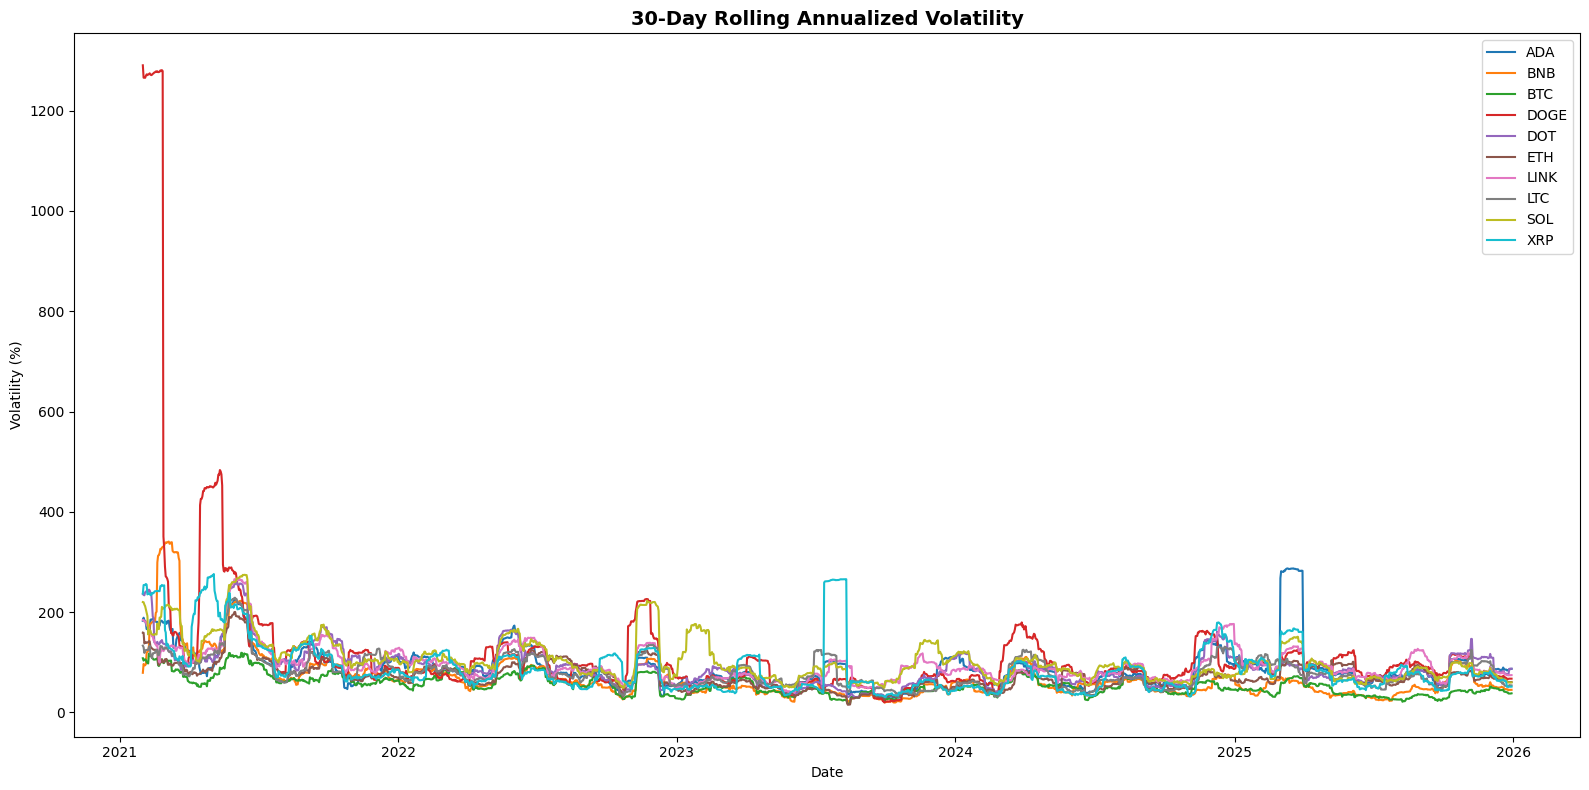

Saved: rolling_volatility_all.png


In [ ]:
returns_pivot = df.pivot(index="Date", columns="Crypto", values="Daily_Return")
rolling_vol = returns_pivot.rolling(30).std() * np.sqrt(365)

plt.figure(figsize=(16, 8))
for crypto in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[crypto], label=crypto)

plt.title("30-Day Rolling Annualized Volatility", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("../data/volatility/rolling_volatility_all.png", dpi=150)
plt.show()
print("Saved: rolling_volatility_all.png")

## Rolling Volatility — Individual Subplots
Individual 30-day rolling volatility charts for each cryptocurrency
allow closer inspection of each coin's risk profile over time.

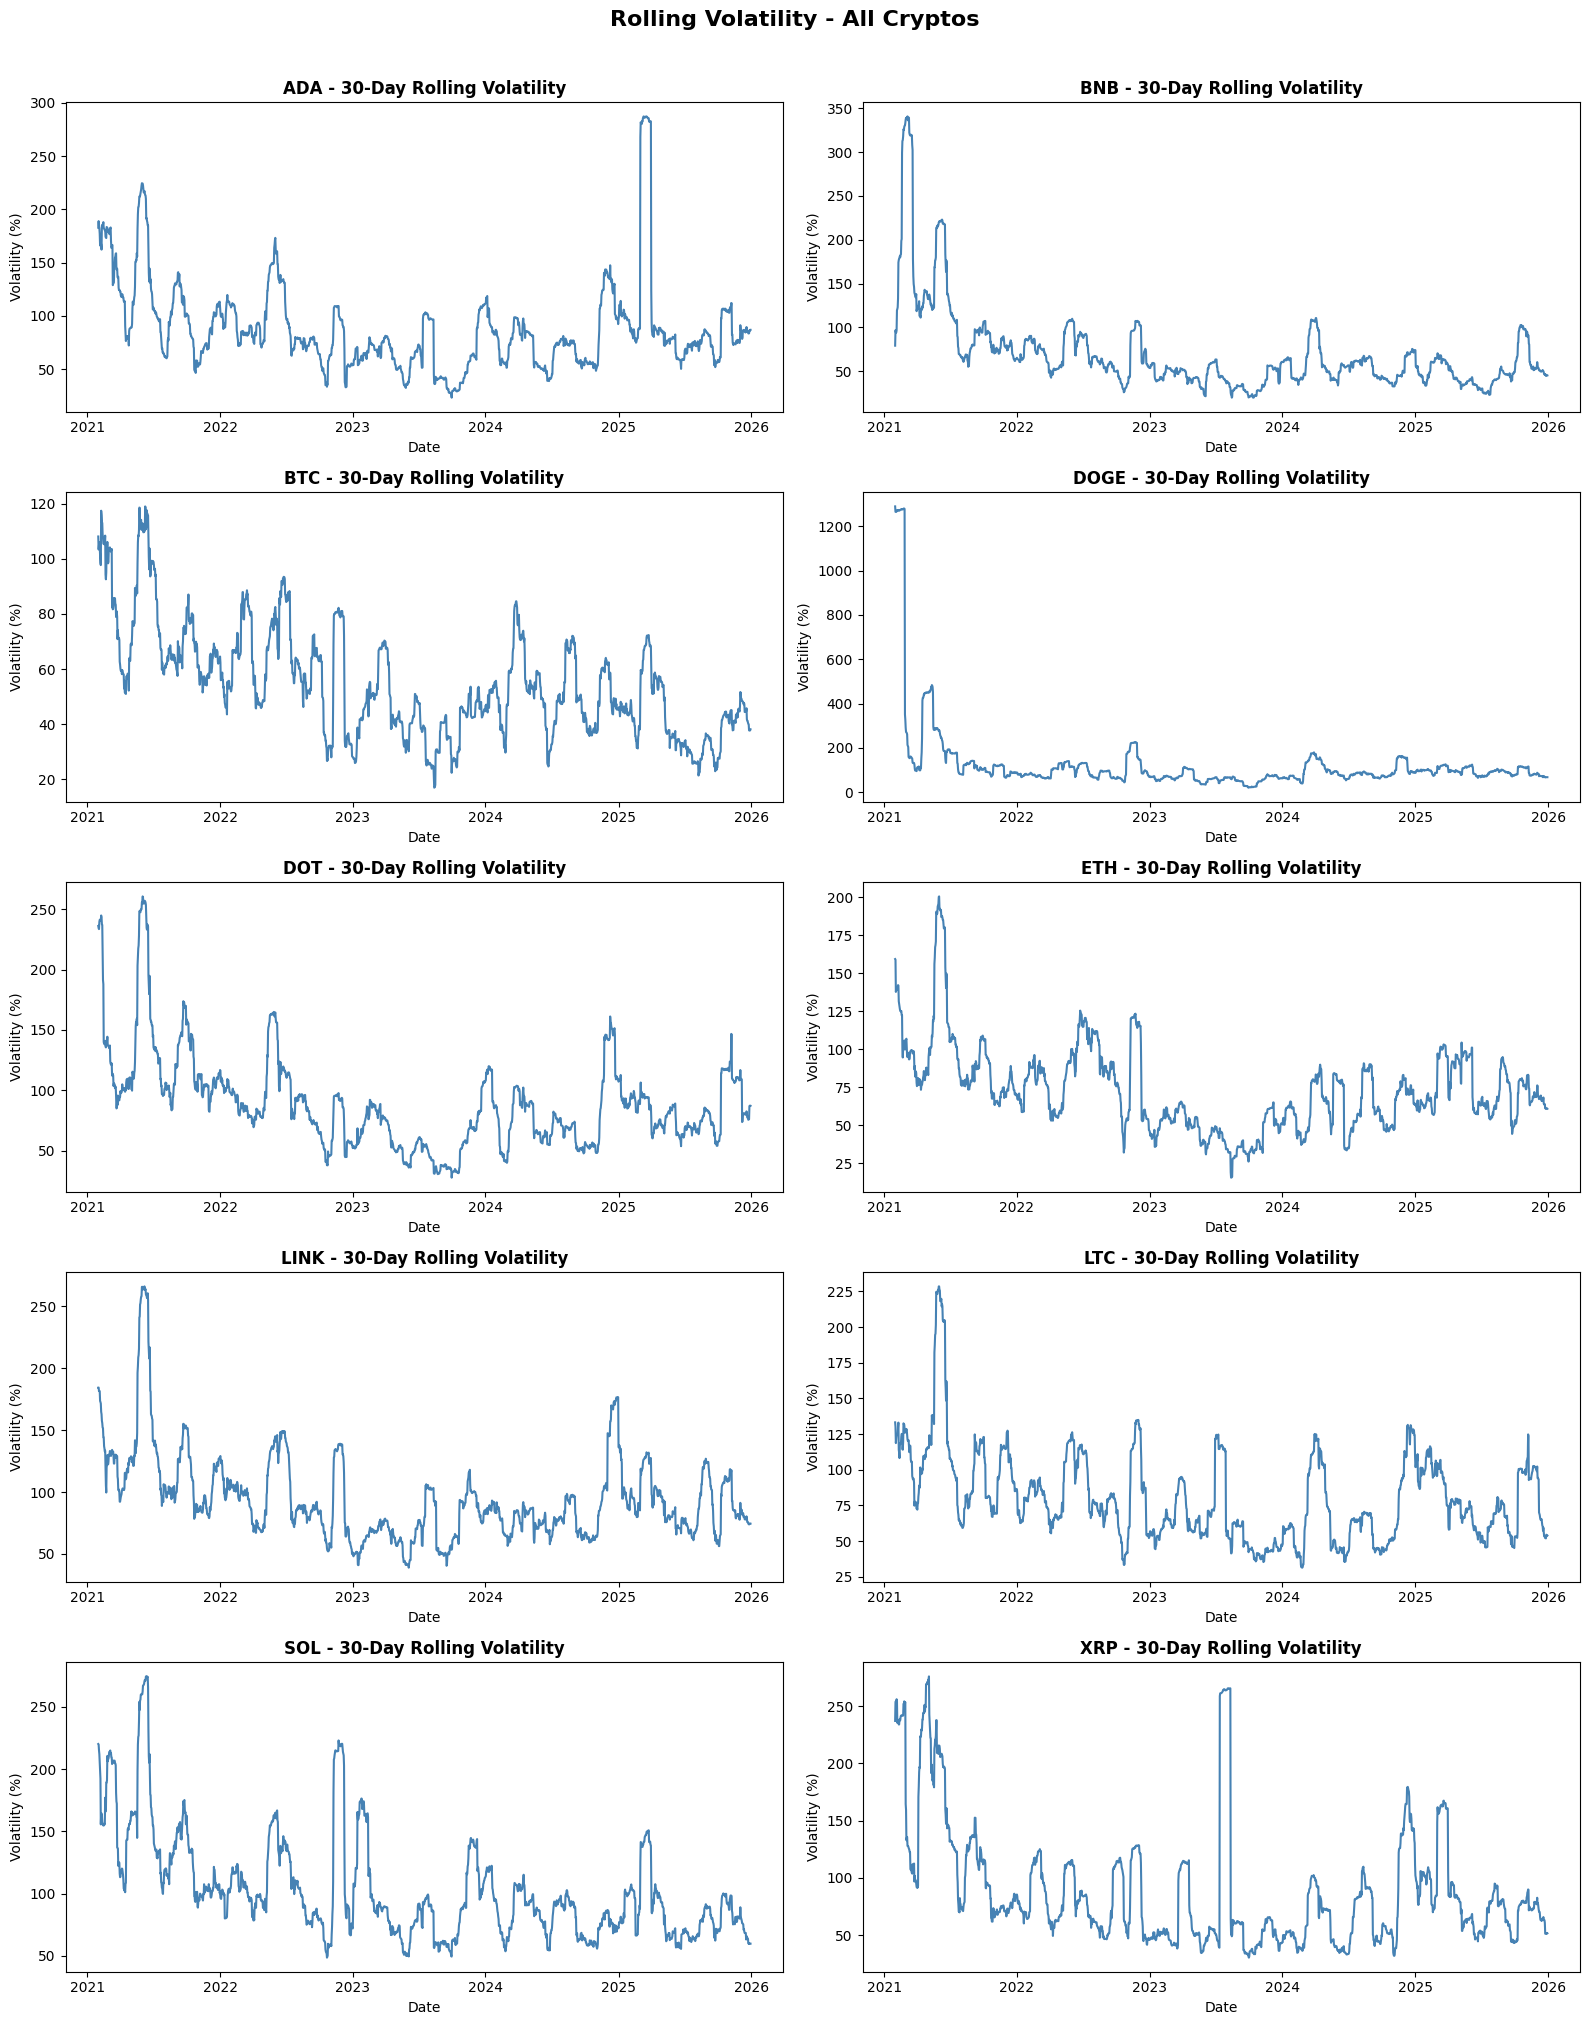

Saved: rolling_volatility_subplots.png


In [ ]:
cryptos = df["Crypto"].unique()
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, crypto in enumerate(cryptos):
    crypto_df = df[df["Crypto"] == crypto].set_index("Date")
    rolling = crypto_df["Daily_Return"].rolling(30).std() * np.sqrt(365)
    axes[i].plot(rolling.index, rolling, color="steelblue")
    axes[i].set_title(f"{crypto} - 30-Day Rolling Volatility", fontweight="bold")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Volatility (%)")

plt.suptitle("Rolling Volatility - All Cryptos", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/volatility/rolling_volatility_subplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: rolling_volatility_subplots.png")

## Daily Return Distribution per Cryptocurrency
Histograms of daily returns reveal the statistical distribution of price changes.

- **Narrow distribution** → stable, low-risk coin
- **Wide distribution** → volatile, high-risk coin
- **Red dashed line** marks zero return (break-even point)
- Most crypto returns follow a **leptokurtic distribution** (fat tails) indicating
  higher probability of extreme price movements than a normal distribution

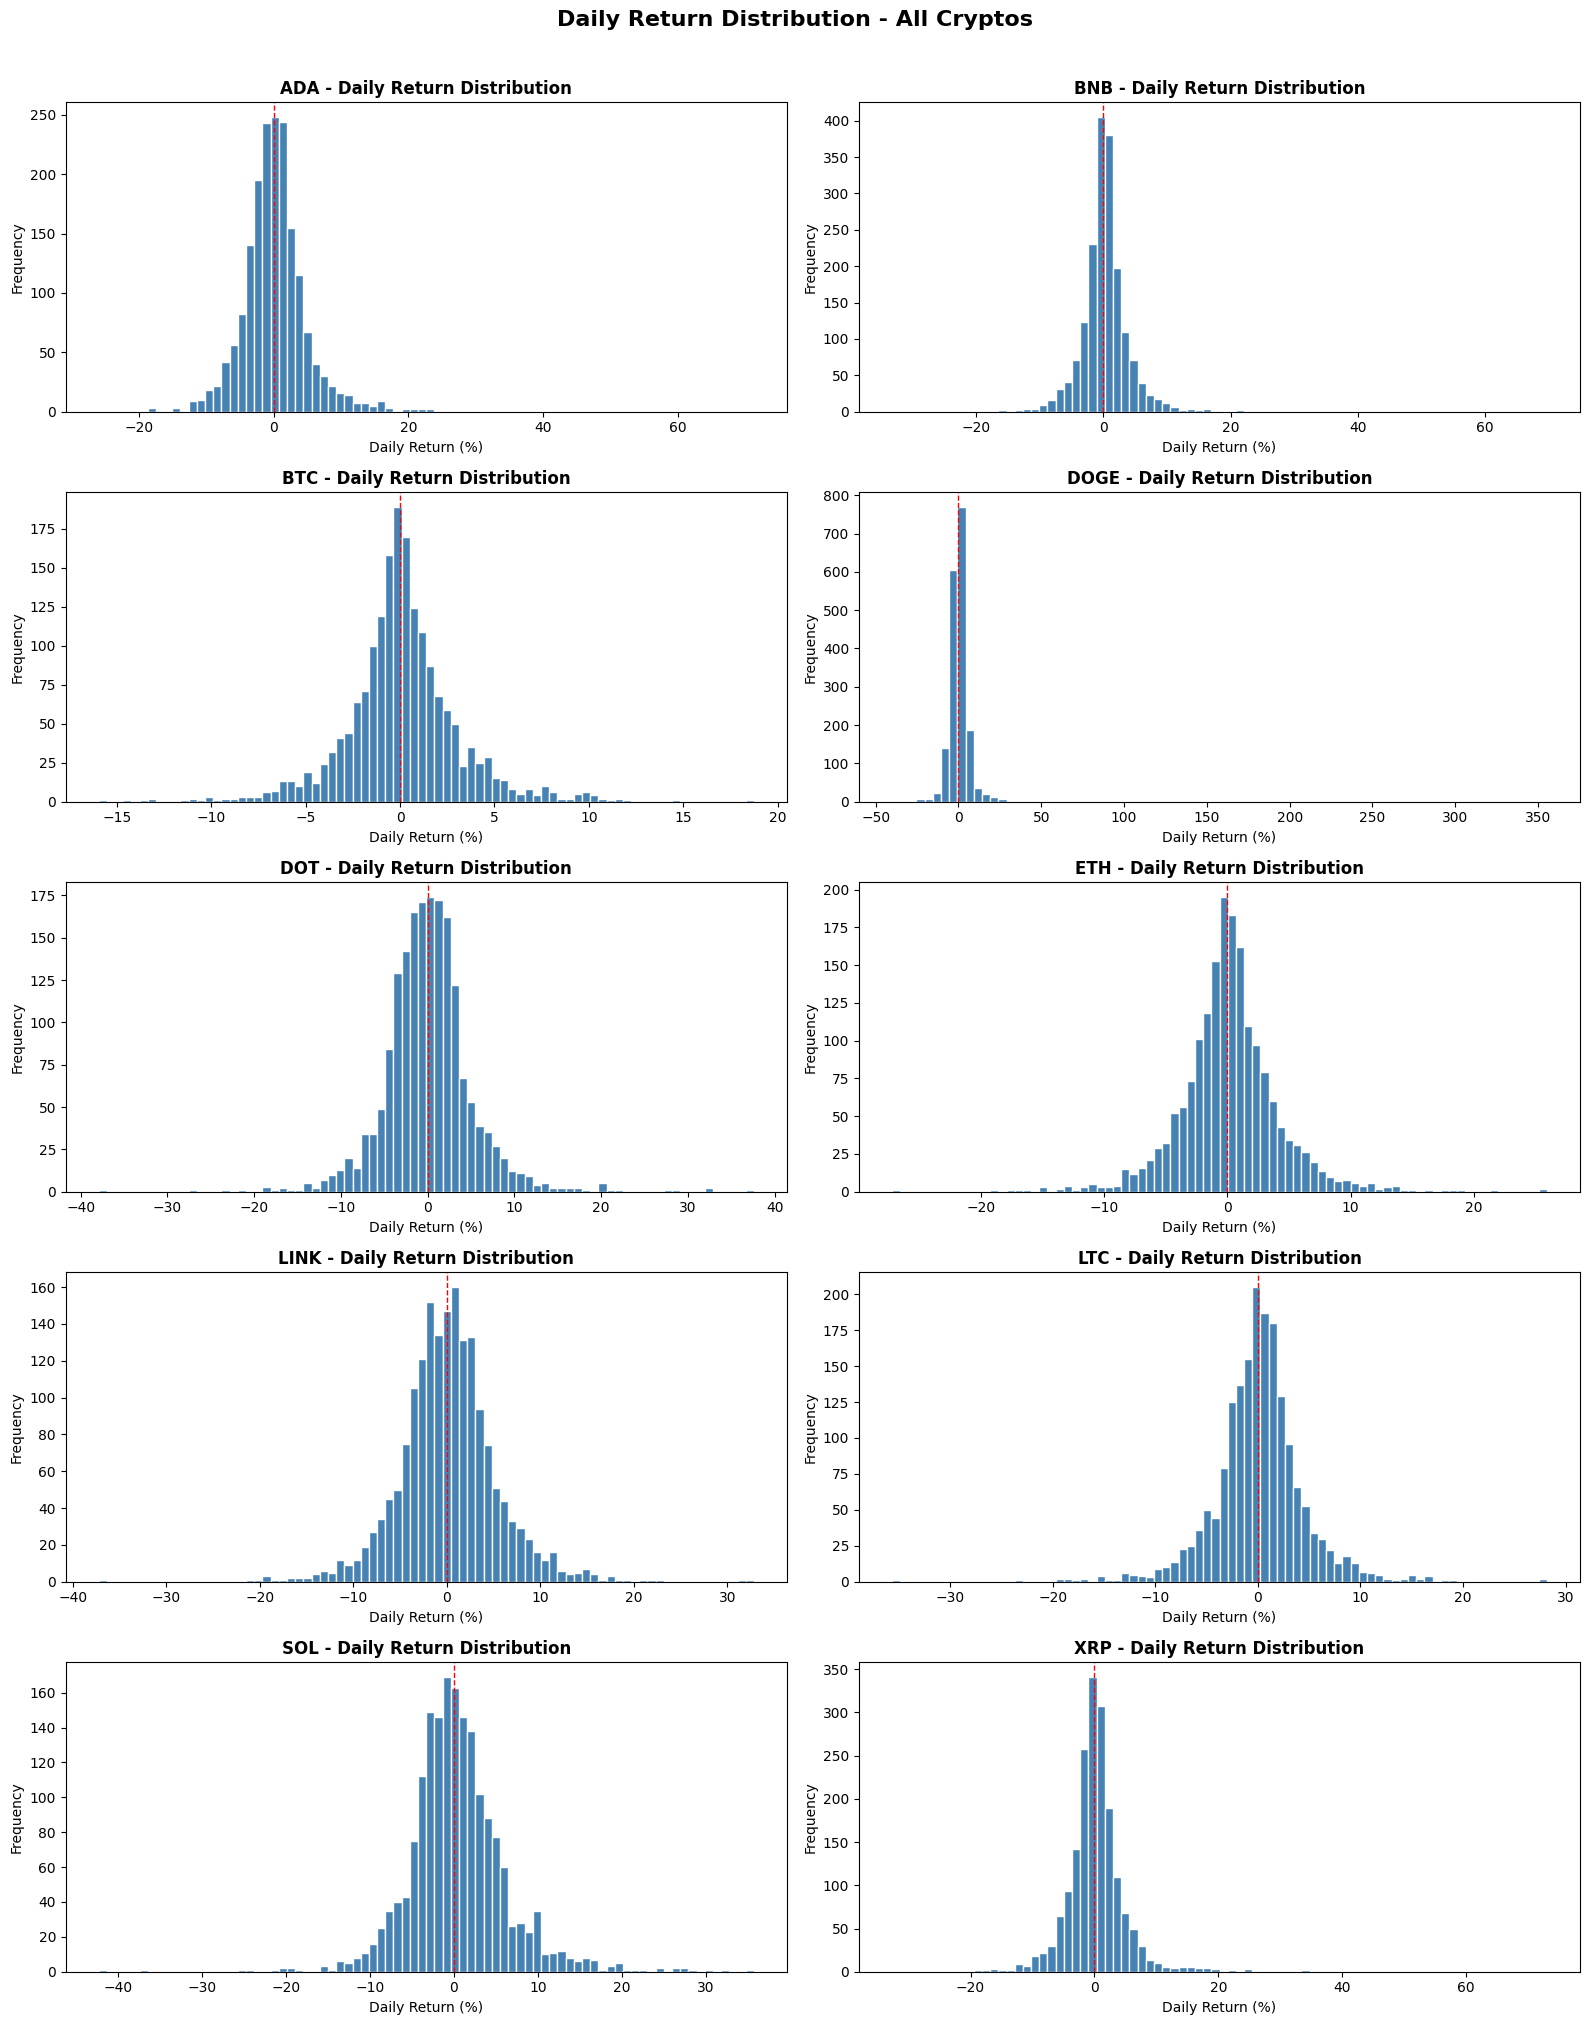

Saved: return_distribution.png


In [ ]:
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, crypto in enumerate(cryptos):
    crypto_df = df[df["Crypto"] == crypto]
    axes[i].hist(crypto_df["Daily_Return"].dropna(), bins=80, color="steelblue", edgecolor="white")
    axes[i].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[i].set_title(f"{crypto} - Daily Return Distribution", fontweight="bold")
    axes[i].set_xlabel("Daily Return (%)")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Daily Return Distribution - All Cryptos", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../data/volatility/return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: return_distribution.png")

## Monthly Volatility Heatmap
This heatmap shows how volatility varied month by month for each cryptocurrency
from 2021 to 2025.

- **Dark red cells** → high volatility months (risky periods)
- **Light yellow cells** → low volatility months (stable periods)

Key periods to observe:
- **Early 2021:** High volatility during crypto bull run
- **Mid 2022:** Extreme volatility during crypto winter / Luna collapse
- **2024:** Moderate increase around Bitcoin halving event

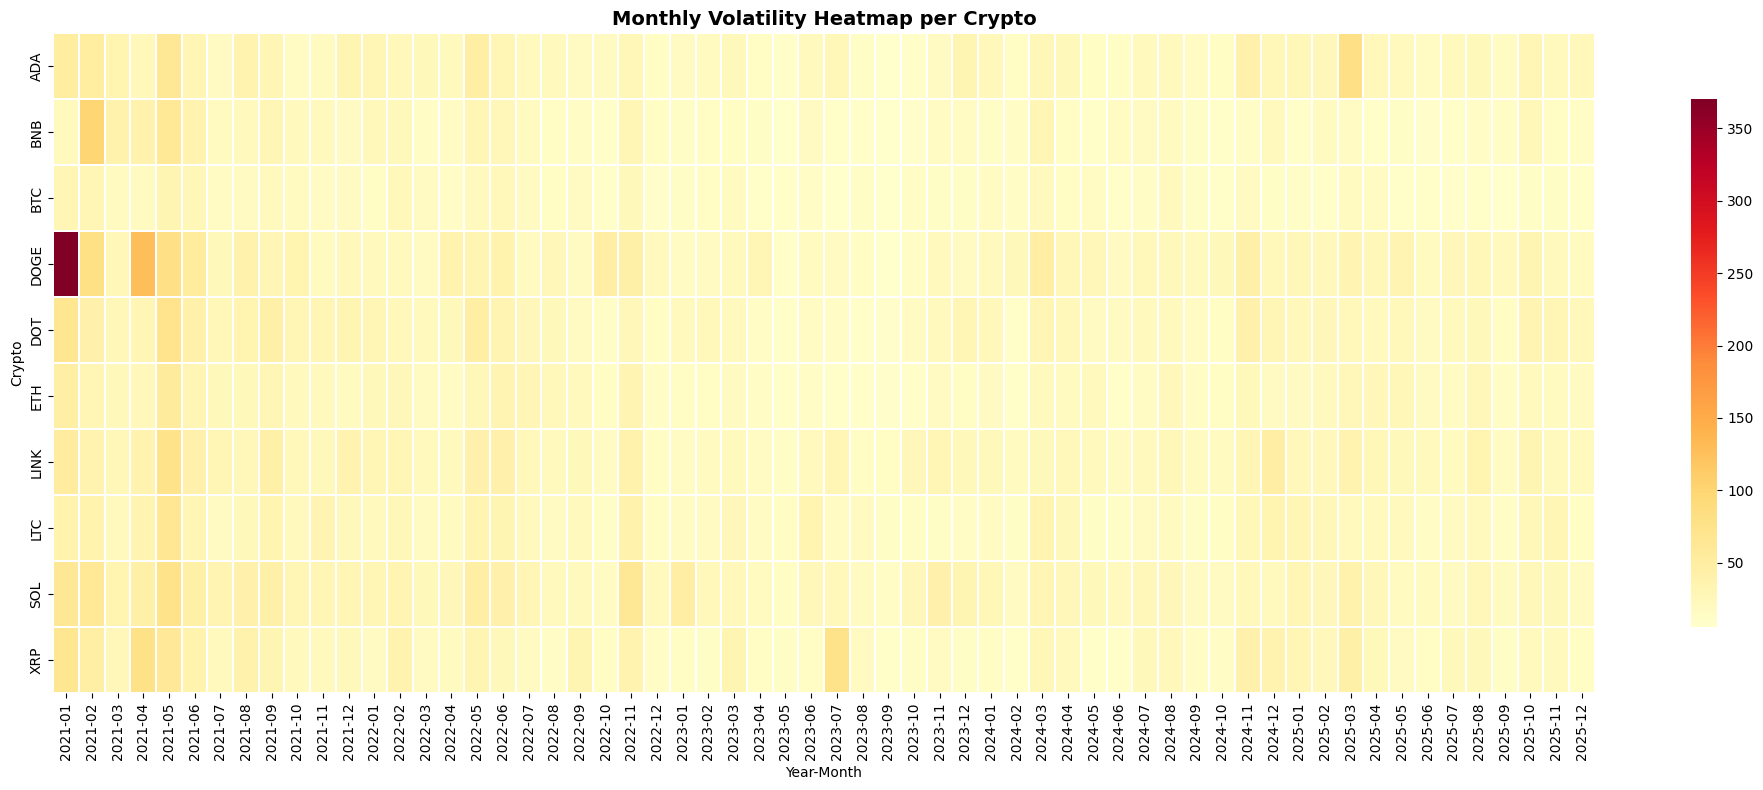

Saved: monthly_volatility_heatmap.png


In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

monthly_vol = df.groupby(["Crypto", "Year", "Month"])["Daily_Return"].std() * np.sqrt(30)
monthly_vol = monthly_vol.reset_index()
monthly_vol["Year_Month"] = monthly_vol["Year"].astype(str) + "-" + monthly_vol["Month"].astype(str).str.zfill(2)

pivot_vol = monthly_vol.pivot(index="Crypto", columns="Year_Month", values="Daily_Return")

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_vol, cmap="YlOrRd", linewidths=0.3, cbar_kws={"shrink": 0.8})
plt.title("Monthly Volatility Heatmap per Crypto", fontsize=14, fontweight="bold")
plt.xlabel("Year-Month")
plt.ylabel("Crypto")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("../data/volatility/monthly_volatility_heatmap.png", dpi=150)
plt.show()
print("Saved: monthly_volatility_heatmap.png")

## Sharpe Ratio — Risk-Adjusted Return
The Sharpe Ratio measures return earned per unit of risk taken.

**Formula:**
$$\text{Sharpe Ratio} = \frac{\mu_{daily}}{\sigma_{daily}} \times \sqrt{365}$$

| Sharpe Ratio | Interpretation |
|-------------|----------------|
| > 2.0 | Excellent |
| 1.0 – 2.0 | Good |
| 0.0 – 1.0 | Acceptable |
| < 0.0 | Poor (negative risk-adjusted return) |

A higher Sharpe Ratio indicates better risk-adjusted performance.

Sharpe Ratio per Crypto:
  Crypto  Sharpe_Ratio
8    SOL      1.308034
1    BNB      1.142758
9    XRP      0.882103
3   DOGE      0.873519
5    ETH      0.749677
2    BTC      0.669212
0    ADA      0.615303
6   LINK      0.516194
7    LTC      0.326306
4    DOT      0.182281


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10768\303362304.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sharpe, x="Crypto", y="Sharpe_Ratio", palette="coolwarm")


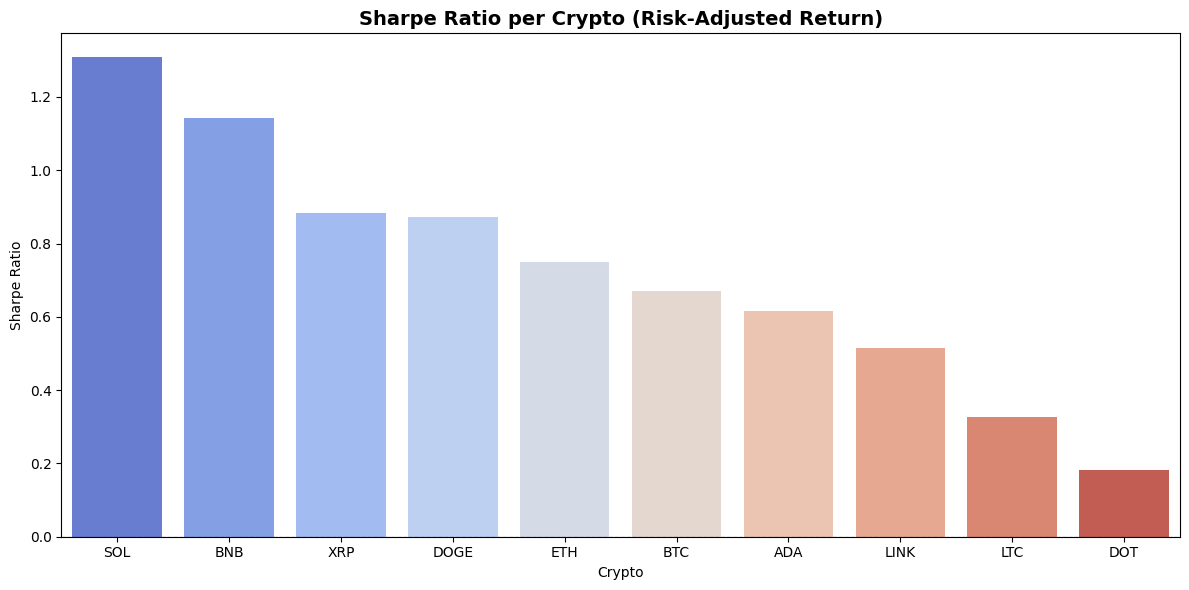

Saved: sharpe_ratio.png


In [ ]:
sharpe = df.groupby("Crypto")["Daily_Return"].apply(
    lambda x: (x.mean() / x.std()) * np.sqrt(365)
).reset_index()
sharpe.columns = ["Crypto", "Sharpe_Ratio"]
sharpe = sharpe.sort_values("Sharpe_Ratio", ascending=False)

print("Sharpe Ratio per Crypto:")
print(sharpe)

plt.figure(figsize=(12, 6))
sns.barplot(data=sharpe, x="Crypto", y="Sharpe_Ratio", palette="coolwarm")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("Sharpe Ratio per Crypto (Risk-Adjusted Return)", fontsize=14, fontweight="bold")
plt.xlabel("Crypto")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig("../data/volatility/sharpe_ratio.png", dpi=150)
plt.show()
print("Saved: sharpe_ratio.png")

## Save Volatility Summary Files
Save annualized volatility and Sharpe ratio summaries as CSV files
for use in the Power BI dashboard.

**Output files saved to `../data/volatility/`:**
- `volatility_summary.csv`
- `sharpe_ratio.csv`

In [ ]:
volatility_summary.to_csv("../data/volatility/volatility_summary.csv", index=False)
sharpe.to_csv("../data/volatility/sharpe_ratio.csv", index=False)

print("Saved: volatility_summary.csv")
print("Saved: sharpe_ratio.csv")

Saved: volatility_summary.csv
Saved: sharpe_ratio.csv


## Summary

| Output | Description | Location |
|--------|-------------|----------|
| annualized_volatility.png | Bar chart of yearly volatility | data/volatility/ |
| rolling_volatility_all.png | All cryptos rolling volatility | data/volatility/ |
| rolling_volatility_subplots.png | Individual rolling volatility | data/volatility/ |
| return_distribution.png | Daily return histograms | data/volatility/ |
| monthly_volatility_heatmap.png | Month-by-month heatmap | data/volatility/ |
| sharpe_ratio.png | Risk-adjusted return chart | data/volatility/ |
| volatility_summary.csv | Annualized volatility values | data/volatility/ |
| sharpe_ratio.csv | Sharpe ratio values | data/volatility/ |

**Key Insights:**
- Crypto markets experienced peak volatility in early 2021 and mid 2022
- SOL, DOGE, and LINK consistently show highest volatility
- BTC and ETH show relatively lower volatility due to higher market capitalization
- Sharpe ratio analysis reveals which coins delivered the best risk-adjusted returns

**Next Step:** `05_prophet_forecasting.ipynb`